# Métodos Computacionales

## Unidad 2:

### Cálculo Numérico

1. Diferenciación numérica

## Introducción.

A lo largo de esta sección, cubriremos el tema del cálculo numérico.  El cálculo es una herramienta muy poderosa y debido a la complejidad cada vez mayor de las expresiones analíticas utilizadas en física y astronomía, su uso se vuelve cada vez más poco práctico, y los enfoques numéricos son más que necesarios cuando se quiere profundizar. Este problema ha sido identificado desde hace mucho tiempo y se han desarrollado muchas técnicas numéricas cubriremos solo los esquemas más básicos, pero también proporcionaremos una base para enfoques más formales, para estas aproximaciones numericas se utiliza el concepto de cuadrícula numérica.

Una **cuadrícula numérica** es un conjunto de puntos espaciados uniformemente sobre el dominio de una función (es decir, la variable independiente), durante algún intervalo. El **espaciado** o **tamaño de paso** de una cuadrícula numérica es la distancia entre puntos adyacentes en la cuadrícula. Para el propósito de este texto, si $x$ es una cuadrícula numérica, entonces $x_j$ es el punto $j^{\mathrm{th}}$ en la cuadrícula numérica y $h$ es el espacio entre $x_{j -1}$ y $x_j$. La siguiente figura muestra un ejemplo de cuadrícula numérica.

![Im1.png](attachment:Im1.png)


Hay varias funciones en Python que se pueden usar para generar cuadrículas numéricas. Para cuadrículas numéricas en una dimensión, es suficiente usar la función *linspace*, que ya ha usado para crear matrices espaciadas regularmente.

En Python, una función $f(x)$ se puede representar en un intervalo calculando su valor en una cuadrícula. Aunque la función en sí puede ser continua, esta representación **discreta** o **discretizada** es útil para cálculos numéricos y corresponde a conjuntos de datos que pueden adquirirse en la práctica de la ingeniería y la ciencia. Específicamente, el valor de la función solo puede conocerse en puntos discretos. Por ejemplo, un sensor de temperatura puede entregar pares de temperatura versus tiempo a intervalos de tiempo regulares. Aunque la temperatura es una función del tiempo suave y continua, el sensor solo proporciona valores a intervalos de tiempo discretos y, en este caso particular, ni siquiera se conocería la función subyacente.

Ya sea que $f$ sea una función analítica o una representación discreta de una, nos gustaría derivar métodos para aproximar la derivada de $f$ sobre una cuadrícula numérica y determinar su precisión.

De acuerdo con la definición formal de diferenciación, dada una función $f(x)$ tal que $f(x)\in C^1[a,b]$ , la derivada de primer orden está dada por

$$\frac{d}{dx}f(x) = f'(x) = \lim_{h\rightarrow 0} \frac{f(x+h)-f(x)}{h}$$

Sin embargo, cuando exhibe una forma compleja o es una función numérica (solo se conoce un conjunto discreto de puntos), esta expresión se vuelve inviable. A pesar de esto, esta fórmula nos da una primera forma aproximada de calcular derivadas numéricas tomando un intervalo finito , $h$ es decir



$$f'(x) \approx \frac{f(x+h)-f(x)}{h}$$


donde la función debe conocerse al menos en $x_0$  y  $x_1 = x_0+h$, graficamente:

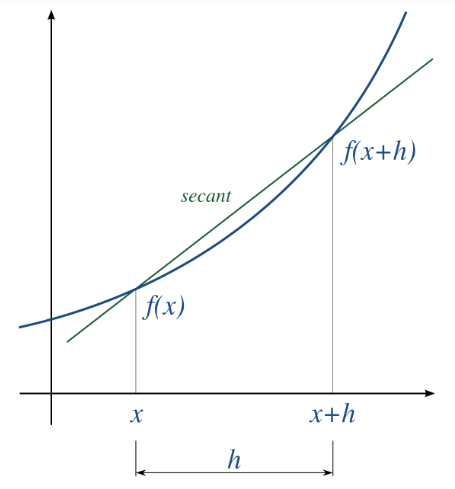

Si tomamos $h$ lo suficientemente pequeña, entonces podemos aproximar esta recta secante a la recta tangente en un punto y así obtenemos la pendiente de dicha recta.

Hay varias fórmulas de diferencias finitas utilizadas en diferentes aplicaciones, y tres de ellas, donde la derivada se calcula utilizando los valores de dos puntos, se presentan a continuación.

La **diferencia hacia adelante** es estimar la pendiente de la función en $ x_j $ usando la línea que conecta $ (x_j, f (x_j)) $ y $ (x_ {j + 1}, f (x_ {j + 1})) $:

$$ f '(x_j) = \frac{f (x_{j + 1}) - f (x_j)}{x_{j+1} -x_j} $$

La **diferencia hacia atrás** es estimar la pendiente de la función en $ x_j $ usando la línea que conecta $ (x_ {j-1}, f (x_ {j-1})) $ y $ (x_j, f (x_j)) $:

$$ f '(x_j) = \frac{f (x_j) - f (x_{j-1})} {x_j - x_{j-1}} $$

La **diferencia central** es estimar la pendiente de la función en $ x_j $ usando la línea que conecta $ (x_ {j-1}, f (x_ {j-1})) $ y $ (x_ {j +1}, f (x_ {j + 1})) $:

$$ f '(x_j) = \frac{f (x_{j + 1}) - f (x_{j-1})} {x_{j + 1} - x_{j-1}} $$

La siguiente figura ilustra los tres tipos diferentes de fórmulas para estimar la pendiente.


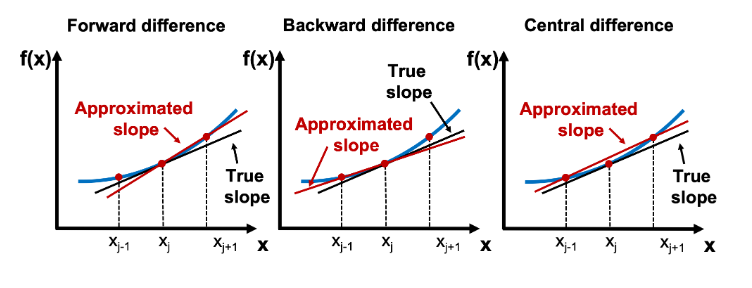

### Ejemplo

$$f(x) =e^{\sin(x)}$$

$$\frac{d}{dx} e^{\sin(x)} = cos(x)e^{sin(x)} $$

In [ ]:
def e(x): #f(x)
    return np.exp(np.sin(x))

def de(x): #f'(x)
    return np.cos(x)*np.exp(np.sin(x))

### Ejercicio
Escriba un programa en Python donde se implemente los tres casos de derivada numérica y aplíquelo a la función ejemplo.

In [ ]:
import numpy as np

def derivative(f,a,method='centrada',h=1e-1):
    if method == 'centrada':
        return (f(a + h) - f(a - h))/(2*h)
    elif method == 'adelante':
        return (f(a + h) - f(a))/h
    elif method == 'atras':
        return (f(a) - f(a - h))/h
    else:
        raise ValueError("Los métodos pueden ser 'centrada', 'adelante' o 'atras'.")

derivative(e,np.pi,method='atras')

-1.049868303316892

### Ejercicio

Para esta misma función evalúe en que dominios funciona mejor cada método, es decir, haga un gráfico y define cuál método es mejor.

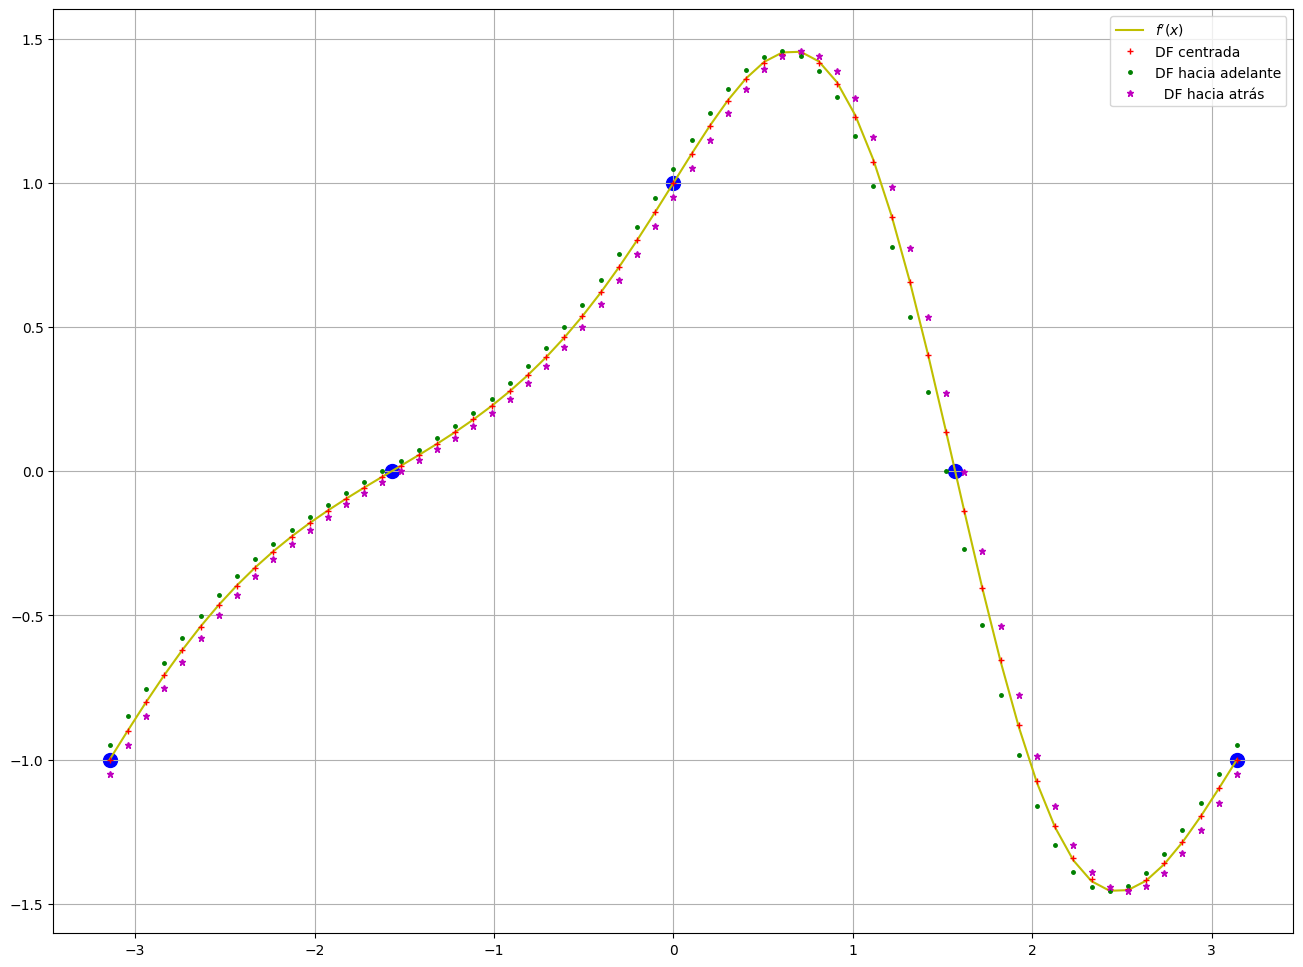

In [ ]:
import matplotlib.pyplot as plt

a=-np.pi
b=np.pi
h=0.1 #tamaño del paso
N=round((b-a)/h) #redondear el resultado, el cual será la cantidad de datos
x = np.linspace(a,b,N)

de_c=derivative(e,x)
de_ad=derivative(e,x,method='adelante')
de_at=derivative(e,x,method='atras')

puntos=np.array([-np.pi,-np.pi/2,0,np.pi/2,np.pi])
y_puntos=derivative(e,puntos)

plt.figure(figsize = (16, 12)) #tamaño del plot

plt.plot(x,de(x), 'y') #derivada  analítica
#Utilizamos h=0.1 solo con fines de visualización
plt.plot(x,de_c,'r+', ms=5) #centrada por defecto
plt.plot(x,de_ad,'g.', ms=5) #adelante
plt.plot(x,de_at,'m* ', ms=5) #atrás

plt.grid()

plt.scatter(puntos,y_puntos, s= 100.,c='b') # s: tamaño del punto, c: color 'b'=blue

plt.legend(["$f'(x)$",'DF centrada','DF hacia adelante','  DF hacia atrás'])

## Aproximada de derivadas con series de Taylor y derivadas de orden superiror

Para obtener una aproximación de la derivada de $ f $, volvemos a la serie de Taylor. Para una función arbitraria $ f (x) $ la serie de Taylor de $ f $ alrededor de $ a = x_j $ es
$$
f(x) = \frac{f(x_j)(x - x_j)^0}{0!} + \frac{f^{\prime}(x_j)(x - x_j)^1}{1!} + \frac{f''(x_j)(x - x_j)^2}{2!} + \frac{f'''(x_j)(x - x_j)^3}{3!} + \cdots.
$$


Si $ x $ está en una cuadrícula de puntos con espaciado $ h $, podemos calcular la serie de Taylor en $ x = x_{j + 1} $ para obtener

$$
f(x_{j+1}) = \frac{f(x_j)(x_{j+1} - x_j)^0}{0!} + \frac{f^{\prime}(x_j)(x_{j+1}- x_j)^1}{1!} + \frac{f''(x_j)(x_{j+1} - x_j)^2}{2!} + \frac{f'''(x_j)(x_{j+1} - x_j)^3}{3!} + \cdots.
$$

Sustituyendo $ h = x_{j + 1} - x_j $ y despejando $ f^{\prime}(x_j) $ da la ecuación

$$
f^{\prime}(x_j) = \frac{f(x_{j+1}) - f(x_j)}{h} + \left(-\frac{f''(x_j)h}{2!} -\frac{f'''(x_j)h^2}{3!} - \cdots\right).
$$

Los términos que están entre paréntesis, $-\frac{f''(x_j)h}{2!} -\frac{f'''(x_j)h^2}{3!} - \cdots$, se llaman **condiciones de pedido más altas** de $ h $. Los términos de orden superior se pueden reescribir como

$$
-\frac{f''(x_j)h}{2!} -\frac{f'''(x_j)h^2}{3!} - \cdots = h(\alpha + \epsilon(h)),
$$

donde $\alpha$ es una constante, y $ \epsilon (h) $ es una función de $ h $ que va a cero cuando $ h $ va a 0. Puedes verificar con algo de álgebra que esto sea cierto. Usamos la abreviatura "$ O (h) $" para $h(\alpha + \epsilon(h))$, y en general, usamos la abreviatura "$ O(h^p) $" para denotar $ h^p(\alpha + \epsilon (h)) $.


Sustituyendo $ O (h) $ en las ecuaciones anteriores se obtiene

$$
f^{\prime}(x_j) = \frac{f(x_{j+1}) - f(x_j)}{h} + O(h).
$$

Esto da la fórmula de **DF hacia adelante** para aproximar derivados como

$$
f^{\prime}(x_j) \approx \frac{f(x_{j+1}) - f(x_j)}{h},
$$

y decimos que esta fórmula es $ O (h) $, de la misma forma podemos hacer lo mismo para las otras dos ecuaciones.

También es posible utilizar la serie de Taylor para aproximar derivadas de orden superior (por ejemplo, $ f '' (x_j), f '' '(x_j) $, etc.). Por ejemplo, tomando la serie de Taylor alrededor de $ a = x_j $ y luego calculándola en $x = x_{j-1} $ y $ x_{j + 1} $ da

$$
f (x_{j-1}) = f (x_j) - hf ^ {\prime} (x_j) + \frac{h^2f '' (x_j)} {2} - \frac{h ^ 3f '' ' (x_j)}{6} + \cdots $$

y

$$ f (x_ {j + 1}) = f(x_j) + hf^{\prime}(x_j) + \frac{h ^ 2f '' (x_j)}{2} + \frac{h^3f ' '' (x_j)}{6} + \cdots. $$

Si sumamos estas dos ecuaciones, obtenemos

$$ f (x_{j-1}) + f (x_{j + 1}) = 2f (x_j) + h ^ 2f '' (x_j) + \frac{h ^ 4f '' '' (x_j)}{24} + \cdots, $$

y con alguna reordenación da la aproximación
$$ f '' (x_j) \approx \frac{f (x_ {j + 1}) - 2f (x_j) + f (x_ {j-1})}{h^2}, $$

y es $ O (h ^ 2) $.

Ahora Considere la notación:
$$ f '' (x_j) \approx \frac{f (x_ {j + 1}) - 2f (x_j) + f (x_ {j-1})}{h^2}, $$

$$ f '' (x_j) \approx \frac{f_1 - 2f_0 + f_{-1}}{h^4} $$

Donde esta es la formula de derivada central de orden $h^2$


Entonce, la segunda derivada adelante y atras de $O(h^2)$ son:

Adelante:

$$ f '' (x_0) \approx \frac{2f_0 - 5f_1 +4f2-f_3}{h^2} $$

Atras

$$ f '' (x_0) \approx \frac{2f_0 - 5f_{-1} +4f_{-2}-f_{-3}}{h^2} $$

### Tarea:

In [ ]:

def derivada( x1 , metodo , funcion):
  h = 0.0000000000001
  if metodo == "adelante":
    x = ( (2*funcion(x1)) - (5*funcion(x1+h)) + (4*funcion(x+h+h)) - funcion(x+h+h+h)) / ( h**2)
  elif metodo == "atras":
    x = ( (2*funcion(x1)) - (5*funcion(x1-h)) + (4*funcion(x-h-h)) - funcion(x-h-h-h)) / ( h**2)
  elif metodo == "central" :
    x = ( funcion(x1+h) - (2*funcion(x))  + funcion(x1-h) ) /  (h**2)
  else:
    print("Debes escoger entre diferenciacion adelante, atras o central")
  return x

#**DIFERENCIACION**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.misc import derivative

FUNCION

In [ ]:
def funcion1(x):
  x = np.exp(np.sin(x))
  return x

def funcion1_deriv(x):
  x = np.cos(x) * np.exp(np.sin(x))
  return x

def funcion1_2deriv(x):
  x = ( (np.cos(x)**2) * np.exp(np.sin(x)) ) - ( np.sin(x)*np.exp(np.sin(x)))
  return x

##Diferenciacion Numerica I

In [ ]:
def derivada( x1 , metodo , funcion):
  #punto1 y punto2 listas
  h = 0.0000000000001
  if metodo == "adelante":
    x = ( funcion(x1+h) - funcion(x1) ) / ( (x1+h) - x1)
  elif metodo == "atras":
    x = ( funcion(x1) - funcion(x1-h) ) / ( x1 - (x1-h) )
  elif metodo == "central" :
    x = ( funcion(x1+h) -  funcion(x1-h) ) / ( (x1+h)- (x1-h) )
  else:
    print("Debes escoger entre diferenciacion adelante, atras o central")
  return x

##Diferenciacion Numerica II (Taylor)

In [ ]:

def derivada_taylor( x1 , metodo , funcion):
  h = 0.1
  if metodo == "adelante":
    x = ( (2*funcion(x1)) - (5*funcion(x1+h)) + (4*funcion(x1+h+h)) - funcion(x1+h+h+h)) / ( h**2)
  elif metodo == "atras":
    x = ( (2*funcion(x1)) - (5*funcion(x1-h)) + (4*funcion(x1-h-h)) - funcion(x1-h-h-h)) / ( h**2)
  elif metodo == "central" :
    x = ( funcion(x1+h) - 2*funcion(x1) + funcion(x1-h) ) /  (h**2)
  else:
    print("Debes escoger entre diferenciacion adelante, atras o central")
  return x

##Diferenciacion Numerica III (Scipy)

In [ ]:
def f(x):
  y = np.exp(np.sin(x))  #Definir la Funcion
  return y
x = 3
derivative(f , x , dx = 0.0001)  #Usar la funcion de la libreria sympy

<ipython-input-6-920ff5dfa63d>:5: DeprecationWarning: scipy.misc.derivative is deprecated in SciPy v1.10.0; and will be completely removed in SciPy v1.12.0. You may consider using findiff: https://github.com/maroba/findiff or numdifftools: https://github.com/pbrod/numdifftools
  derivative(f , x , dx = 0.0001)  #Usar la funcion de la libreria sympy


-1.1400385666737733

##Diferenciacion Simbolica

In [ ]:
x = sp.Symbol("x")
fx = sp.exp(sp.sin(x))
deriv1_fx = fx.diff(x)
deriv2_fx = deriv1_fx.diff(x)

In [ ]:
f = sp.lambdify( x , fx , 'numpy')
dx= sp.lambdify( x , deriv1_fx  , 'numpy')
dx2 = sp.lambdify(x , deriv2_fx , 'numpy')